<a href="https://colab.research.google.com/github/MIL-Project2/DR-DT/blob/main/Occupancy_Prediction_Ver1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Set your user info (Git is already installed!)
!git config --global user.email "jwas0006@student.monash.edu"
!git config --global user.name "MIL-Project2"

# 2. Clone your repo (if you haven't already)
!git clone https://github.com/MIL-Project2/DR-DT.git
%cd DR-DT

# 3. Make your changes or add new files...

# 4. Push back to GitHub
!git add .
!git commit -m "Updated from Colab"

# 5. Push using your Personal Access Token (paste it when prompted for a password)
!git push

Cloning into 'DR-DT'...
remote: Enumerating objects: 125, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 125 (delta 67), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (125/125), 2.78 MiB | 6.05 MiB/s, done.
Resolving deltas: 100% (67/67), done.
/content/DR-DT
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [2]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
df = pd.read_csv('Occupancy-Prediction_Generated_Ver_1_2.csv', delimiter=',')

In [4]:
# ── Missing Values, Data Types & Duplicates ──────────────────────────────────
print("=== DATA AUDIT REPORT ===")
column_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Missing Values': df.isnull().sum(),
    'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
display(column_info)
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nStatistical Summary:")
display(df.describe().round(2))

=== DATA AUDIT REPORT ===


,Data Type,Non-Null Count,Missing Values,Missing (%)
collecteddate,object,54759,0,0.0
floorspaceid,object,54759,0,0.0
headcount,int64,54759,0,0.0
temperature,float64,0,54759,100.0
humidity,float64,0,54759,100.0
co2,float64,0,54759,100.0



Duplicate Rows: 0

Statistical Summary:


,headcount,temperature,humidity,co2
count,54759.00,0.0,0.0,0.0
mean,2.24,NaN,NaN,NaN
std,2.85,NaN,NaN,NaN
min,0.00,NaN,NaN,NaN
25%,1.00,NaN,NaN,NaN
50%,2.00,NaN,NaN,NaN
75%,3.00,NaN,NaN,NaN
max,21.00,NaN,NaN,NaN


## **Exploratory Data Analysis (EDA)**

This section consolidates and extends the EDA. The analysis is structured around two research questions:

- **Q1:** What is the distribution of the target variable “headcount"?
- **Q2:** Which numerical features are most strongly correlated with “headcount”?

### **The distribution of the target variable “headcount"**

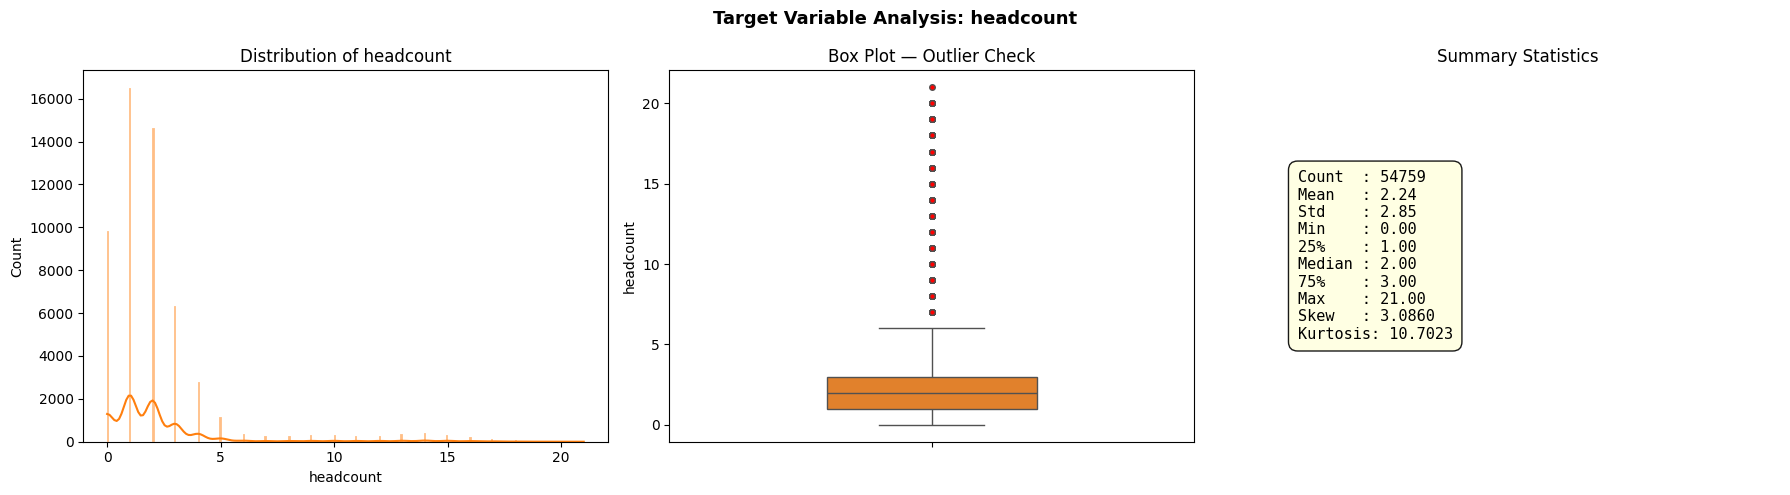

Skewness : 3.0860  (|skew| < 0.5 = approx. normal)
Kurtosis : 10.7023
IQR-based outliers : 3208 (5.9%)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE
sns.histplot(df['headcount'], kde=True, ax=axes[0], color='tab:orange', edgecolor='white')
axes[0].set_title('Distribution of headcount')
axes[0].set_xlabel('headcount'); axes[0].set_ylabel('Count')

# Box plot — outlier check
sns.boxplot(y=df['headcount'], ax=axes[1], color='tab:orange', width=0.4,
            flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
axes[1].set_title('Box Plot — Outlier Check')
axes[1].set_ylabel('headcount')

# Summary statistics panel
desc = df['headcount'].describe()
lines = [f"Count  : {desc['count']:.0f}",
         f"Mean   : {desc['mean']:.2f}",
         f"Std    : {desc['std']:.2f}",
         f"Min    : {desc['min']:.2f}",
         f"25%    : {desc['25%']:.2f}",
         f"Median : {desc['50%']:.2f}",
         f"75%    : {desc['75%']:.2f}",
         f"Max    : {desc['max']:.2f}",
         f"Skew   : {df['headcount'].skew():.4f}",
         f"Kurtosis: {df['headcount'].kurtosis():.4f}"]
axes[2].axis('off')
axes[2].text(0.08, 0.5, '\n'.join(lines), transform=axes[2].transAxes,
             fontsize=11, verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow', alpha=0.9))
axes[2].set_title('Summary Statistics')

plt.suptitle('Target Variable Analysis: headcount', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

print(f"Skewness : {df['headcount'].skew():.4f}  (|skew| < 0.5 = approx. normal)")
print(f"Kurtosis : {df['headcount'].kurtosis():.4f}")
q1, q3 = df['headcount'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df[(df['headcount'] < q1 - 1.5*iqr) | (df['headcount'] > q3 + 1.5*iqr)]
print(f"IQR-based outliers : {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

### **Numerical features are most strongly correlated with “headcount”**

Pearson Correlation with Headcount (sorted by absolute value):
             Correlation
temperature          NaN
humidity             NaN
co2                  NaN


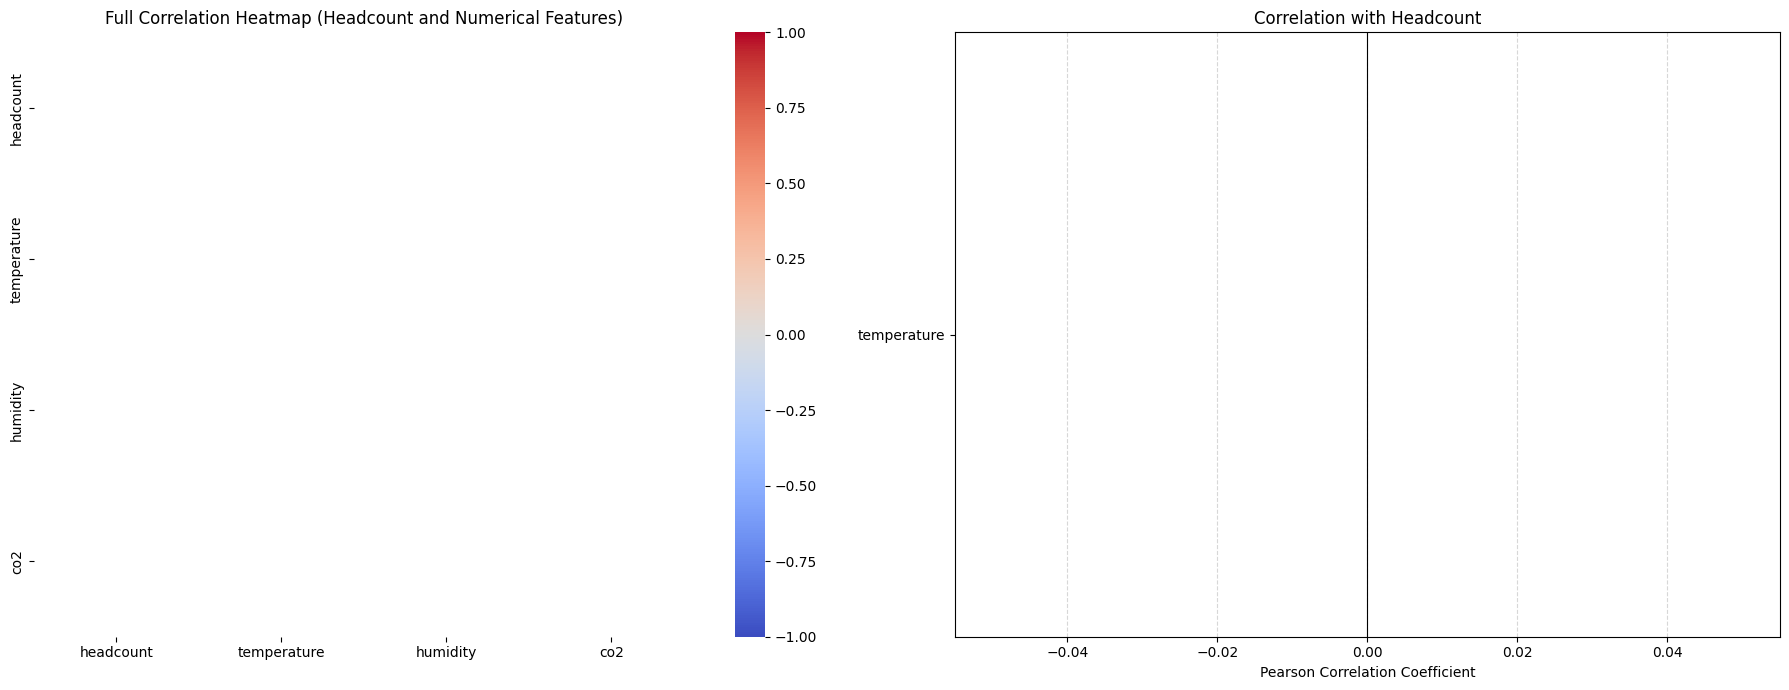

In [6]:
import numpy as np
# Identify numerical features relevant for correlation with 'headcount'
numerical_features = [
    'temperature', 'humidity', 'co2'
]

# Ensure 'headcount' is included for correlation calculation
cols_for_corr = ['headcount'] + numerical_features

# Calculate correlation matrix
corr_matrix_headcount = df[cols_for_corr].corr()

# Correlation with headcount (sorted by absolute value)
headcount_corr = corr_matrix_headcount['headcount'].drop('headcount').sort_values(key=abs, ascending=False)
print("Pearson Correlation with Headcount (sorted by absolute value):")
print(headcount_corr.to_frame('Correlation').round(4))

# Visualize correlations with heatmap and bar chart
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full correlation heatmap (only for the selected numerical features and headcount)
mask = np.triu(np.ones_like(corr_matrix_headcount, dtype=bool))
sns.heatmap(corr_matrix_headcount, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, ax=axes[0], linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title('Full Correlation Heatmap (Headcount and Numerical Features)', fontsize=12)

# Bar chart of correlations with headcount
colors_headcount = ['#d73027' if v > 0 else '#4575b4' for v in headcount_corr.values]
axes[1].barh(headcount_corr.index, headcount_corr.values, color=colors_headcount)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with Headcount', fontsize=12)
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
for i, v in enumerate(headcount_corr.values):
    axes[1].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## **Data Cleaning & Preprocessing**

This section outlines the data cleaning and preprocessing steps necessary to prepare the `df` DataFrame for machine learning tasks. Building upon the initial data audit and EDA, this stage focuses on:

1.  **5 Minutes Interval Data**: Add the `target_time` column
2.  **DateTime Conversion**: Converting the `target_time` column to datetime objects and extracting useful time-based features (e.g., `hour_of_day`, `day_of_week`) that might influence occupancy.
3.  **Feature Engineering**: Adding `occupancy_lag_5min`,	`occupancy_lag_10min`,	`occupancy_lag_15min`,	`occupancy_rolling_15min`,	`co2_rolling_15min`,	`temperature_rolling_15min`.
4.  **Outlier Strategy**: Deciding on an approach to handle the outliers identified in the `headcount` target variable and other numerical features.
5.  **Feature Scaling**: Applying appropriate scaling techniques to numerical features to ensure they are on a comparable scale for various machine learning algorithms.

### **5 Minutes Interval Data**

In [7]:
print("Original dtype:", df['collecteddate'].dtype)
print("First 5 values:\n", df['collecteddate'].head())
print("Any non-string values?", df['collecteddate'].apply(type).value_counts())

Original dtype: object
First 5 values:
 0    2024-07-08 05:27:44+10
1    2024-07-08 05:28:42+10
2    2024-07-08 05:29:04+10
3    2024-07-08 05:40:44+10
4    2024-07-08 05:41:22+10
Name: collecteddate, dtype: object
Any non-string values? collecteddate
<class 'str'>    54759
Name: count, dtype: int64


In [8]:
# 1. Strip the timezone offset (+XX) from the strings
df['collecteddate'] = df['collecteddate'].astype(str).str.replace(r'\+.*$', '', regex=True)

# Now parse as naive (local time)
df['collecteddate'] = pd.to_datetime(
    df['collecteddate'],
    errors='coerce'
)

# 2. Remove the timezone to make them naive (local wall-clock times)
#    This converts e.g. 2024-07-08 05:27:44+10:00 -> 2024-07-08 05:27:44 (naive)
df['collecteddate'] = df['collecteddate'].dt.tz_localize(None)

# 3. Drop any rows that failed conversion
df = df.dropna(subset=['collecteddate']).copy()

# Verify
print("New dtype:", df['collecteddate'].dtype)   # datetime64[ns]
print("Sample:", df['collecteddate'].head())

# 4. Proceed with the rest (sort, per-minute, 5-min targets, merge)
df = df.sort_values('collecteddate').reset_index(drop=True)
df['minute'] = df['collecteddate'].dt.floor('min')

minute_latest = df.drop_duplicates(subset='minute', keep='last').copy()
minute_latest = minute_latest.set_index('minute').sort_index()

start = df['collecteddate'].min().floor('D')
end = df['collecteddate'].max().ceil('D') - pd.Timedelta('1min')
targets = pd.date_range(start=start, end=end, freq='5min')

result = pd.merge_asof(
    pd.DataFrame({'target_time': targets}),
    minute_latest,
    left_on='target_time',
    right_index=True,
    direction='backward',
    tolerance=pd.Timedelta('3min')
)

result = result.dropna(subset=['collecteddate']).drop(columns=['minute'], errors='ignore')

display(result)

New dtype: datetime64[ns]
Sample: 0   2024-07-08 05:27:44
1   2024-07-08 05:28:42
2   2024-07-08 05:29:04
3   2024-07-08 05:40:44
4   2024-07-08 05:41:22
Name: collecteddate, dtype: datetime64[ns]


,target_time,collecteddate,floorspaceid,headcount,temperature,humidity,co2
66,2024-07-08 05:30:00,2024-07-08 05:29:04,9f902aab-58fe-4b1c-ab24-241310df1550,0.0,NaN,NaN,NaN
68,2024-07-08 05:40:00,2024-07-08 05:40:44,9f902aab-58fe-4b1c-ab24-241310df1550,1.0,NaN,NaN,NaN
116,2024-07-08 09:40:00,2024-07-08 09:39:04,9f902aab-58fe-4b1c-ab24-241310df1550,0.0,NaN,NaN,NaN
118,2024-07-08 09:50:00,2024-07-08 09:50:04,9f902aab-58fe-4b1c-ab24-241310df1550,0.0,NaN,NaN,NaN
119,2024-07-08 09:55:00,2024-07-08 09:55:44,9f902aab-58fe-4b1c-ab24-241310df1550,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...
27500,2024-10-11 11:40:00,2024-10-11 11:40:58,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN
27501,2024-10-11 11:45:00,2024-10-11 11:45:46,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN
27502,2024-10-11 11:50:00,2024-10-11 11:50:48,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN
27503,2024-10-11 11:55:00,2024-10-11 11:55:36,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN


### **Create a full 5-minute index from start to end**

In [9]:
# 1. Create a full 5-minute index from start to end
full_index = pd.date_range(
    start=result['target_time'].min(),
    end=result['target_time'].max(),
    freq='5min'
)

# Reindex the result to this full index
# (this inserts NaN rows for missing 5-minute intervals)
result_2 = (
    result
    .set_index('target_time')          # use target_time as index
    .reindex(full_index)               # fill in all 5-minute slots
    .reset_index()
    .rename(columns={'index': 'target_time'})
)

display(result_2)

,target_time,collecteddate,floorspaceid,headcount,temperature,humidity,co2
0,2024-07-08 05:30:00,2024-07-08 05:29:04,9f902aab-58fe-4b1c-ab24-241310df1550,0.0,NaN,NaN,NaN
1,2024-07-08 05:35:00,NaT,NaN,NaN,NaN,NaN,NaN
2,2024-07-08 05:40:00,2024-07-08 05:40:44,9f902aab-58fe-4b1c-ab24-241310df1550,1.0,NaN,NaN,NaN
3,2024-07-08 05:45:00,NaT,NaN,NaN,NaN,NaN,NaN
4,2024-07-08 05:50:00,NaT,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
27434,2024-10-11 11:40:00,2024-10-11 11:40:58,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN
27435,2024-10-11 11:45:00,2024-10-11 11:45:46,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN
27436,2024-10-11 11:50:00,2024-10-11 11:50:48,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN
27437,2024-10-11 11:55:00,2024-10-11 11:55:36,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN


### **Add Day and Hour Columns**

In [10]:
result_2['day_of_week'] = result_2['target_time'].dt.dayofweek
result_2['hour_of_day'] = result_2['target_time'].dt.hour

display(result_2)

,target_time,collecteddate,floorspaceid,headcount,temperature,humidity,co2,day_of_week,hour_of_day
0,2024-07-08 05:30:00,2024-07-08 05:29:04,9f902aab-58fe-4b1c-ab24-241310df1550,0.0,NaN,NaN,NaN,0,5
1,2024-07-08 05:35:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5
2,2024-07-08 05:40:00,2024-07-08 05:40:44,9f902aab-58fe-4b1c-ab24-241310df1550,1.0,NaN,NaN,NaN,0,5
3,2024-07-08 05:45:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5
4,2024-07-08 05:50:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5
...,...,...,...,...,...,...,...,...,...
27434,2024-10-11 11:40:00,2024-10-11 11:40:58,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11
27435,2024-10-11 11:45:00,2024-10-11 11:45:46,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11
27436,2024-10-11 11:50:00,2024-10-11 11:50:48,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11
27437,2024-10-11 11:55:00,2024-10-11 11:55:36,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11


### **Add Lag Columns**

In [11]:
# Add lag columns (using the full, regular grid)
# Example: add 1 lag (5 minutes ago), 2 lags (10 minutes ago), 3 lags (15 minutes ago) for 'headcount'
result_2['headcount_lag_5min'] = result_2['headcount'].shift(1)
result_2['headcount_lag_10min'] = result_2['headcount'].shift(2)
result_2['headcount_lag_15min'] = result_2['headcount'].shift(3)

# # Add lags for other columns as well (temperature, co2, etc.)
# result_3['temperature_lag1'] = result_3['temperature'].shift(1)
# result_3['co2_lag1'] = result_3['co2'].shift(1)

# Display the final result
display(result_2[['target_time', 'collecteddate', 'headcount', 'headcount_lag_5min','headcount_lag_10min', 'headcount_lag_15min']])

,target_time,collecteddate,headcount,headcount_lag_5min,headcount_lag_10min,headcount_lag_15min
0,2024-07-08 05:30:00,2024-07-08 05:29:04,0.0,NaN,NaN,NaN
1,2024-07-08 05:35:00,NaT,NaN,0.0,NaN,NaN
2,2024-07-08 05:40:00,2024-07-08 05:40:44,1.0,NaN,0.0,NaN
3,2024-07-08 05:45:00,NaT,NaN,1.0,NaN,0.0
4,2024-07-08 05:50:00,NaT,NaN,NaN,1.0,NaN
...,...,...,...,...,...,...
27434,2024-10-11 11:40:00,2024-10-11 11:40:58,3.0,2.0,1.0,1.0
27435,2024-10-11 11:45:00,2024-10-11 11:45:46,3.0,3.0,2.0,1.0
27436,2024-10-11 11:50:00,2024-10-11 11:50:48,3.0,3.0,3.0,2.0
27437,2024-10-11 11:55:00,2024-10-11 11:55:36,3.0,3.0,3.0,3.0


### **Add Rolling Columns**

In [12]:
# Calculate rolling features. For a 15-minute window with 5-minute intervals, this is a 3-period window.
# min_periods=1 allows calculation even with fewer than 3 values at the start.
result_2['headcount_rolling_15min'] = result_2['headcount'].rolling(window=3, min_periods=1).mean()

# # Add rolling for other columns as well (temperature, co2, etc.)
# df['co2_rolling_15min'] = df['co2'].rolling(window=3, min_periods=1).mean()
# df['temperature_rolling_15min'] = df['temperature'].rolling(window=3, min_periods=1).mean()

display(result_2)

,target_time,collecteddate,floorspaceid,headcount,temperature,humidity,co2,day_of_week,hour_of_day,headcount_lag_5min,headcount_lag_10min,headcount_lag_15min,headcount_rolling_15min
0,2024-07-08 05:30:00,2024-07-08 05:29:04,9f902aab-58fe-4b1c-ab24-241310df1550,0.0,NaN,NaN,NaN,0,5,NaN,NaN,NaN,0.000000
1,2024-07-08 05:35:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5,0.0,NaN,NaN,0.000000
2,2024-07-08 05:40:00,2024-07-08 05:40:44,9f902aab-58fe-4b1c-ab24-241310df1550,1.0,NaN,NaN,NaN,0,5,NaN,0.0,NaN,0.500000
3,2024-07-08 05:45:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5,1.0,NaN,0.0,1.000000
4,2024-07-08 05:50:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5,NaN,1.0,NaN,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27434,2024-10-11 11:40:00,2024-10-11 11:40:58,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,2.0,1.0,1.0,2.000000
27435,2024-10-11 11:45:00,2024-10-11 11:45:46,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,3.0,2.0,1.0,2.666667
27436,2024-10-11 11:50:00,2024-10-11 11:50:48,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,3.0,3.0,2.0,3.000000
27437,2024-10-11 11:55:00,2024-10-11 11:55:36,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,3.0,3.0,3.0,3.000000


### **Outlier Strategy**

In [13]:
# Capping outliers for 'headcount' using the 1st and 99th percentiles
lower_bound = result_2['headcount'].quantile(0.01)
upper_bound = result_2['headcount'].quantile(0.99)

result_2['headcount'] = np.where(result_2['headcount'] < lower_bound, lower_bound,
                           np.where(result_2['headcount'] > upper_bound, upper_bound, result_2['headcount']))

print(f"'headcount' capped: Lower bound {lower_bound:.2f}, Upper bound {upper_bound:.2f}")

display(result_2)

'headcount' capped: Lower bound 0.00, Upper bound 5.00


,target_time,collecteddate,floorspaceid,headcount,temperature,humidity,co2,day_of_week,hour_of_day,headcount_lag_5min,headcount_lag_10min,headcount_lag_15min,headcount_rolling_15min
0,2024-07-08 05:30:00,2024-07-08 05:29:04,9f902aab-58fe-4b1c-ab24-241310df1550,0.0,NaN,NaN,NaN,0,5,NaN,NaN,NaN,0.000000
1,2024-07-08 05:35:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5,0.0,NaN,NaN,0.000000
2,2024-07-08 05:40:00,2024-07-08 05:40:44,9f902aab-58fe-4b1c-ab24-241310df1550,1.0,NaN,NaN,NaN,0,5,NaN,0.0,NaN,0.500000
3,2024-07-08 05:45:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5,1.0,NaN,0.0,1.000000
4,2024-07-08 05:50:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5,NaN,1.0,NaN,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27434,2024-10-11 11:40:00,2024-10-11 11:40:58,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,2.0,1.0,1.0,2.000000
27435,2024-10-11 11:45:00,2024-10-11 11:45:46,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,3.0,2.0,1.0,2.666667
27436,2024-10-11 11:50:00,2024-10-11 11:50:48,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,3.0,3.0,2.0,3.000000
27437,2024-10-11 11:55:00,2024-10-11 11:55:36,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,3.0,3.0,3.0,3.000000


### **Feature Scaling**

In [14]:
# Identify numerical columns for scaling, excluding 'headcount' (target) and identifier/datetime columns.
# Also exclude newly generated lag/rolling features which are also numerical.
numerical_cols_to_scale = [
    'temperature', 'humidity', 'co2',
    'headcount_lag_5min', 'headcount_lag_10min', 'headcount_lag_15min',
    'occupancy_rolling_15min'
]

# Ensure these columns exist and are of numeric type
numerical_cols_to_scale = [col for col in numerical_cols_to_scale if col in result_2.columns and pd.api.types.is_numeric_dtype(result_2[col])]

scaler = StandardScaler()
result_2[numerical_cols_to_scale] = scaler.fit_transform(result_2[numerical_cols_to_scale])

print("Numerical features scaled successfully.")
display(result_2)

Numerical features scaled successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


,target_time,collecteddate,floorspaceid,headcount,temperature,humidity,co2,day_of_week,hour_of_day,headcount_lag_5min,headcount_lag_10min,headcount_lag_15min,headcount_rolling_15min
0,2024-07-08 05:30:00,2024-07-08 05:29:04,9f902aab-58fe-4b1c-ab24-241310df1550,0.0,NaN,NaN,NaN,0,5,NaN,NaN,NaN,0.000000
1,2024-07-08 05:35:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5,-0.734952,NaN,NaN,0.000000
2,2024-07-08 05:40:00,2024-07-08 05:40:44,9f902aab-58fe-4b1c-ab24-241310df1550,1.0,NaN,NaN,NaN,0,5,NaN,-0.734779,NaN,0.500000
3,2024-07-08 05:45:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5,-0.013851,NaN,-0.734605,1.000000
4,2024-07-08 05:50:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5,NaN,-0.013616,NaN,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27434,2024-10-11 11:40:00,2024-10-11 11:40:58,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,0.707249,-0.013616,-0.013380,2.000000
27435,2024-10-11 11:45:00,2024-10-11 11:45:46,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,1.428350,0.707547,-0.013380,2.666667
27436,2024-10-11 11:50:00,2024-10-11 11:50:48,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,1.428350,1.428710,0.707845,3.000000
27437,2024-10-11 11:55:00,2024-10-11 11:55:36,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,1.428350,1.428710,1.429070,3.000000


### **Correlation Heatmap for Features Engineering and Scaled Features**

Key considerations for this dataset's correlation visualization:
- **Numerical Features**: The `temperature`, `humidity`, `co2`, `headcount_lag_5min`, `headcount_lag_10min`, `headcount_lag_15min`, `headcount_rolling_15min`, `hour_of_day`, and `day_of_week` features have already been scaled using `StandardScaler` in the main DataFrame.
- **Target Variable**: We will use `headcount_capped` for correlation analysis to account for outlier handling.
- **Categorical Features**: `deviceid` and `floorspaceid` are categorical. If they were to be included in a numerical correlation heatmap, they would require appropriate encoding (e.g., One-Hot Encoding) beforehand. However, for now, we focus on the numerical relationships.

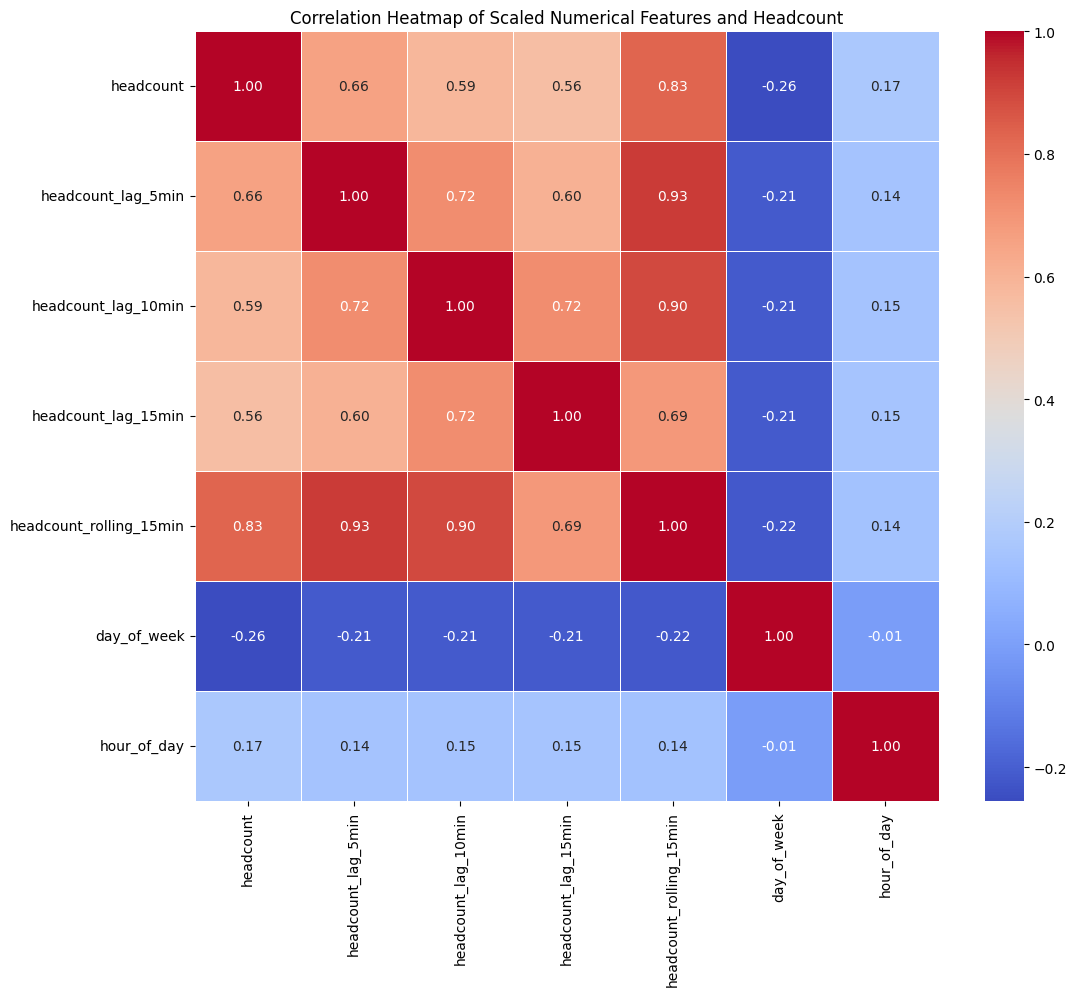

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare the list of numerical columns for correlation, including the target 'headcount'
# Exclude 'timestamp', 'deviceid', 'floorspaceid', and 'day_of_week' (categorical)
correlation_cols = [
    'headcount',
    'headcount_lag_5min', 'headcount_lag_10min', 'headcount_lag_15min',
    'headcount_rolling_15min',
    'day_of_week', 'hour_of_day'
]

# Ensure all selected columns exist in the DataFrame
correlation_cols = [col for col in correlation_cols if col in result_2.columns]

# Calculate the correlation matrix
correlation_matrix = result_2[correlation_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Scaled Numerical Features and Headcount')
plt.show()

### **Add Working-Hour Categories**

In [16]:
result_2['is_working_hour'] = ((result_2['target_time'].dt.hour >= 8) &
                               (result_2['target_time'].dt.hour < 18)).astype(int)
result_2['is_weekend'] = (result_2['target_time'].dt.dayofweek >= 5).astype(int)
result_2['working_weekday_hour'] = ((result_2['is_working_hour'] == 1) &
                                    (result_2['is_weekend'] == 0)).astype(int)

display(result_2)

,target_time,collecteddate,floorspaceid,headcount,temperature,humidity,co2,day_of_week,hour_of_day,headcount_lag_5min,headcount_lag_10min,headcount_lag_15min,headcount_rolling_15min,is_working_hour,is_weekend,working_weekday_hour
0,2024-07-08 05:30:00,2024-07-08 05:29:04,9f902aab-58fe-4b1c-ab24-241310df1550,0.0,NaN,NaN,NaN,0,5,NaN,NaN,NaN,0.000000,0,0,0
1,2024-07-08 05:35:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5,-0.734952,NaN,NaN,0.000000,0,0,0
2,2024-07-08 05:40:00,2024-07-08 05:40:44,9f902aab-58fe-4b1c-ab24-241310df1550,1.0,NaN,NaN,NaN,0,5,NaN,-0.734779,NaN,0.500000,0,0,0
3,2024-07-08 05:45:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5,-0.013851,NaN,-0.734605,1.000000,0,0,0
4,2024-07-08 05:50:00,NaT,NaN,NaN,NaN,NaN,NaN,0,5,NaN,-0.013616,NaN,1.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27434,2024-10-11 11:40:00,2024-10-11 11:40:58,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,0.707249,-0.013616,-0.013380,2.000000,1,0,1
27435,2024-10-11 11:45:00,2024-10-11 11:45:46,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,1.428350,0.707547,-0.013380,2.666667,1,0,1
27436,2024-10-11 11:50:00,2024-10-11 11:50:48,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,1.428350,1.428710,0.707845,3.000000,1,0,1
27437,2024-10-11 11:55:00,2024-10-11 11:55:36,9f902aab-58fe-4b1c-ab24-241310df1550,3.0,NaN,NaN,NaN,4,11,1.428350,1.428710,1.429070,3.000000,1,0,1
